Entorno 'CartPole-v1' cargado. Observaciones: 4, Acciones: 2

--- Iniciando Entrenamiento (dqn) ---
(dqn) Ep: 50/600, Avg Reward: 24.18, Avg Est Q: 5.211, Eps: 0.878
(dqn) Ep: 100/600, Avg Reward: 35.68, Avg Est Q: 19.619, Eps: 0.753
(dqn) Ep: 150/600, Avg Reward: 43.16, Avg Est Q: 41.063, Eps: 0.628
(dqn) Ep: 200/600, Avg Reward: 45.86, Avg Est Q: 64.080, Eps: 0.503
(dqn) Ep: 250/600, Avg Reward: 87.04, Avg Est Q: 93.782, Eps: 0.378
(dqn) Ep: 300/600, Avg Reward: 107.80, Avg Est Q: 116.334, Eps: 0.253
(dqn) Ep: 350/600, Avg Reward: 183.36, Avg Est Q: 140.257, Eps: 0.128
(dqn) Ep: 400/600, Avg Reward: 398.44, Avg Est Q: 143.144, Eps: 0.003
(dqn) Ep: 450/600, Avg Reward: 351.60, Avg Est Q: 149.355, Eps: 0.001
(dqn) Ep: 500/600, Avg Reward: 443.38, Avg Est Q: 131.457, Eps: 0.001
(dqn) Ep: 550/600, Avg Reward: 332.44, Avg Est Q: 142.250, Eps: 0.001
(dqn) Ep: 600/600, Avg Reward: 460.10, Avg Est Q: 181.960, Eps: 0.001
--- Entrenamiento Finalizado (dqn) ---
Evaluando política final DQN...
V

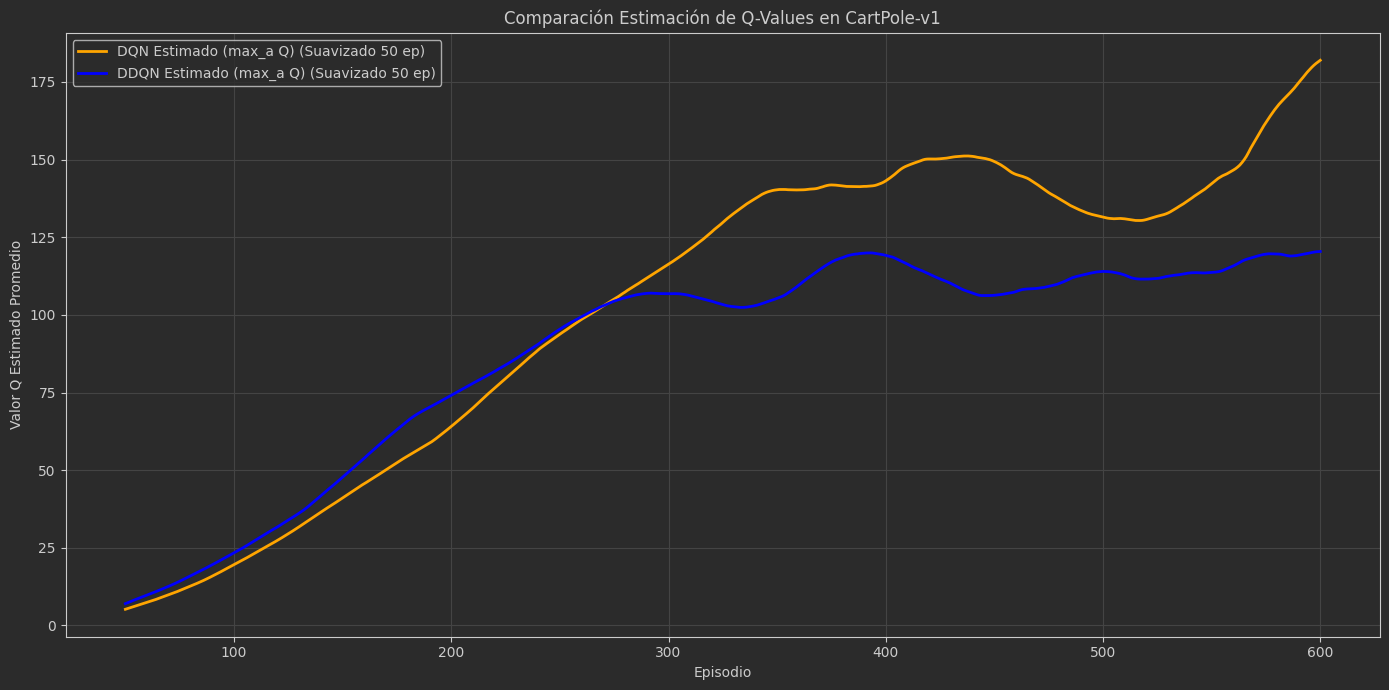


--- Ejecución Completa Finalizada ---


In [1]:
# @title Comparativa entre DQN y Double DQN

import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import random
import numpy as np
import collections
import matplotlib.pyplot as plt
import copy # Para copiar redes

# Modo oscuro para los gráficos
plt.rcParams.update({
    'figure.facecolor': '#2b2b2b',     # fondo exterior
    'axes.facecolor':   '#2b2b2b',     # fondo del área del gráfico
    'axes.edgecolor':   '#cccccc',     # borde de los ejes
    'axes.labelcolor':  '#cccccc',     # etiquetas de los ejes
    'xtick.color':      '#cccccc',     # color de los números en el eje X
    'ytick.color':      '#cccccc',     # color de los números en el eje Y
    'text.color':       '#cccccc',     # color del título y textos
    'grid.color':       '#444444',     # color de la grilla
})

# --- Hiperparámetros ---
max_episodes = 600        # Número de episodios
max_steps_per_episode = 500 # Límite de pasos por episodio
learning_rate = 0.001     # Tasa de aprendizaje
gamma = 0.99              # Factor de descuento
epsilon_start = 1.0       # Epsilon inicial
epsilon_end = 0.001       # Epsilon final
epsilon_decay_episodes = 400 # Episodios para decaimiento de epsilon
buffer_size = 10000       # Tamaño del Replay Buffer
batch_size = 64           # Tamaño del lote para aprender
target_update_freq = 100  # Frecuencia actualización de la Red Objetivo (en steps)
print_every = 50          # Imprimir por consola el progreso cada N episodios
smoothing_window = 50     # Ventana para suavizar curvas en gráficos
evaluation_episodes = 50  # Episodios para la evaluación final del valor real

# --- Entorno (Global para simplicidad en funciones) ---
env_name = 'CartPole-v1'

# --- Red Neuronal (Q-Network) ---
def create_q_network(n_observations, n_actions):
    """Crea la arquitectura de la red Q."""
    return nn.Sequential(
        nn.Linear(n_observations, 128),
        nn.ReLU(),
        nn.Linear(128, 128),
        nn.ReLU(),
        nn.Linear(128, n_actions)
    )

# --- Función de Evaluación (Calcula Retorno Descontado Promedio Real) ---
def evaluate_policy(network, env_name, n_episodes, gamma, max_steps=500):
    """Evalúa una política dada por la red y calcula el retorno descontado promedio."""
    eval_env = gym.make(env_name)
    total_discounted_return = 0.0
    network.eval() # Poner la red en modo evaluación

    for i in range(n_episodes):
        obs, info = eval_env.reset()
        state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        done = False
        episode_discounted_return = 0.0
        discount_factor = 1.0
        steps = 0
        while not done and steps < max_steps:
            with torch.no_grad():
                q_values = network(state)
                # Elegir la acción greedy (sin exploración en evaluación)
                action = q_values.max(1)[1].view(1, 1)

            obs, reward, terminated, truncated, info = eval_env.step(action.item())
            done = terminated or truncated

            episode_discounted_return += discount_factor * reward
            discount_factor *= gamma # Aplicar descuento para la recompensa del siguiente paso
            steps += 1

            if not done:
                state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

        total_discounted_return += episode_discounted_return

    eval_env.close()
    network.train() # Volver a poner la red en modo entrenamiento si se va a seguir usando
    return total_discounted_return / n_episodes

# --- Función de Entrenamiento ---
def train(algorithm_type, env_name, n_observations, n_actions):
    """Entrena un agente DQN o DDQN y devuelve resultados."""
    print(f"\n--- Iniciando Entrenamiento ({algorithm_type}) ---")

    # Crear redes
    q_network = create_q_network(n_observations, n_actions)
    target_network = create_q_network(n_observations, n_actions)
    target_network.load_state_dict(q_network.state_dict())
    target_network.eval() # Red objetivo

    # Optimizador y pérdida
    optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    # Replay Buffer
    replay_buffer = collections.deque(maxlen=buffer_size)
    Transition = collections.namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

    # Variables de seguimiento
    global_step = 0
    epsilon = epsilon_start
    episode_rewards_history = []
    episode_estimated_q_history = [] # Historial de Q estimado (max_a Q_online)

    train_env = gym.make(env_name)

    for episode in range(max_episodes):
        obs, info = train_env.reset()
        state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0) # Estado inicial como Tensor
        episode_reward = 0
        episode_steps = 0
        episode_q_sum = 0.0
        episode_q_count = 0

        # Bucle de pasos dentro del episodio
        for step in range(max_steps_per_episode):
            global_step += 1
            episode_steps += 1

            #  1: Verific estado al inicio del paso ---
            if state is None:
                print(f"Advertencia: El estado es None al inicio del paso {step} en episodio {episode}. Terminando episodio.")
                break # No se puede continuar sin un estado válido

            # --- Selección de Acción (Epsilon-Greedy) ---
            if random.random() < epsilon:
                action = torch.tensor([[train_env.action_space.sample()]], dtype=torch.long) # Exploración
            else:
                with torch.no_grad():
                    # Explotación: usa la red online (estado garantizado no None aquí)
                    q_values = q_network(state)
                    action = q_values.max(1)[1].view(1, 1)

            # --- Ejec. de Acción en el Entorno ---
            next_obs, reward, terminated, truncated, info = train_env.step(action.item())
            done = terminated or truncated
            episode_reward += reward

            # Preparac. datos para la transición
            reward_tensor = torch.tensor([reward], dtype=torch.float32)
            # next_state es None solo si el episodio TERMINÓ (no si fue truncado)
            next_state = None if terminated else torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0)
            done_tensor = torch.tensor([done], dtype=torch.bool) # Guardar si terminó O fue truncado

            # --- Guardar Transición en el Buffer ---
            # state aquí es el estado ANTES de tomar la acción
            replay_buffer.append(Transition(state, action, reward_tensor, next_state, done_tensor))

            # Actualizar el estado para la SIGUIENTE iteración (puede volverse None aquí)
            state = next_state

            # --- Aprendizaje desde el Replay Buffer ---
            if len(replay_buffer) >= batch_size:
                # Muestrear lote
                transitions = random.sample(replay_buffer, batch_size)
                batch = Transition(*zip(*transitions))

                # 2: Verific. si hay None en los estados del lote ---
                if any(s is None for s in batch.state):
                    print(f"Error Crítico: Se encontró None en batch.state en episodio {episode}, paso de aprendizaje {global_step}. Omitiendo lote.")
                    #  depuración se podria agregar
                    continue # Omitir este paso de aprendizaje

                # --- Procesar Lote ---
                state_batch = torch.cat(batch.state)
                action_batch = torch.cat(batch.action)
                reward_batch = torch.cat(batch.reward)
                done_batch = torch.cat(batch.done) # Tensor booleano [batch_size]

                # Crear máscara para estados NO finales (done es False)
                non_final_mask = ~done_batch # Shape [batch_size]

                # Crear batch de next_states, manejando None para los finales
                next_state_list = []
                for ns in batch.next_state:
                    if ns is None: # Estado era terminal
                        # Placeholder con forma correcta (1, obs_dim)
                        next_state_list.append(torch.zeros_like(state_batch[0].unsqueeze(0)))
                    else:
                        next_state_list.append(ns)
                next_state_batch = torch.cat(next_state_list) # Shape [batch_size, obs_dim]

                # Seleccionar solo los next_states que NO son finales usando la máscara
                non_final_next_states = next_state_batch[non_final_mask] # Shape [num_non_final, obs_dim]

                # --- Estimación Q del estado actual 's' (para la curva de estimación) ---
                with torch.no_grad():
                    online_q_values_current = q_network(state_batch)
                    max_online_q_current = online_q_values_current.max(1)[0]
                    episode_q_sum += max_online_q_current.sum().item()
                    episode_q_count += state_batch.size(0) # Promedio sobre todos los estados del batch

                # --- Cálculo del Target Q-Value V(s') ---
                # Inicializar targets futuros a 0. Solo se sobreescribirán los no finales.
                next_state_values = torch.zeros(batch_size)

                # Solo calcular Q(s', a') si hay algún estado no final en el lote
                if non_final_next_states.size(0) > 0:
                    with torch.no_grad():
                        # Calc. Q_target(s', a') para todas las acciones 'a'
                        target_next_q_values_all = target_network(non_final_next_states) # Shape [num_non_final, n_actions]

                        if algorithm_type == 'dqn':
                            # DQN: max directo sobre Q_target(s', a')
                            dqn_max_vals, _ = target_next_q_values_all.max(dim=1) # Shape [num_non_final]
                            next_state_values[non_final_mask] = dqn_max_vals
                        elif algorithm_type == 'ddqn':
                            # DDQN: Usa red online para elegir acción, red target para evaluar
                            online_next_q_values = q_network(non_final_next_states) # Shape [num_non_final, n_actions]
                            online_best_next_actions = online_next_q_values.argmax(dim=1, keepdim=True) # Shape [num_non_final, 1]
                            # Obtenc. del valor Q de la red target para la acción elegida por la online
                            selected_target_next_q_values = target_next_q_values_all.gather(1, online_best_next_actions).squeeze(1) # Shape [num_non_final]
                            next_state_values[non_final_mask] = selected_target_next_q_values
                        else:
                            raise ValueError("Tipo de algoritmo no válido")

                # Calc. el valor Q objetivo final: r + gamma * V(s') (V(s')=0 si s es final)
                expected_state_action_values = reward_batch + (gamma * next_state_values) # Shape [batch_size]

                # --- Optimizac. la Red Online ---
                # Calc. Q(s,a) predicho para las acciones 'a' tomadas en el estado 's'
                state_action_values = q_network(state_batch).gather(1, action_batch).squeeze(1) # Shape [batch_size]
                loss = loss_fn(state_action_values, expected_state_action_values)
                optimizer.zero_grad()
                loss.backward()
                # Opcional: Clamping de gradiente para estabilidad
                # torch.nn.utils.clip_grad_norm_(q_network.parameters(), max_norm=1.0)
                optimizer.step()

            # --- Actualizar la Red Objetivo (Copia periódica) ---
            if global_step % target_update_freq == 0:
                target_network.load_state_dict(q_network.state_dict())

            # --- Verificar si el episodio terminó ---
            if done:
                break # Salir del bucle de pasos

        # --- Final del Episodio ---
        episode_rewards_history.append(episode_reward)
        # Calcular Q estimado promedio para este episodio
        avg_q_this_episode = episode_q_sum / episode_q_count if episode_q_count > 0 else 0.0
        episode_estimated_q_history.append(avg_q_this_episode)

        # Decaimiento de Epsilon

        # Decaimiento de Epsilon (lineal por episodio)
        epsilon = max(epsilon_end, epsilon_start - (episode / epsilon_decay_episodes) * (epsilon_start - epsilon_end))

        # Impresion progreso periódicamente
        if (episode + 1) % print_every == 0:
            # Calc. métricas promedio recientes para imprimir
            avg_reward = np.mean(episode_rewards_history[-print_every:])
            avg_q = np.mean(episode_estimated_q_history[-print_every:])
            print(f'({algorithm_type}) Ep: {episode + 1}/{max_episodes}, Avg Reward: {avg_reward:.2f}, Avg Est Q: {avg_q:.3f}, Eps: {epsilon:.3f}')

    # Fin del bucle de entrenamiento
    train_env.close() # Cierre del entorno de entrenamiento
    print(f"--- Entrenamiento Finalizado ({algorithm_type}) ---")

    # Devol. resultados
    return {
        'rewards_history': episode_rewards_history,
        'estimated_q_history': episode_estimated_q_history,
        'final_network': q_network # Devol. de la red online entrenada
    }
# --- Fin de la función train ---


# --- Ejecución Principal ---

# -- Obtenc. dimensiones del entorno --
try:
    temp_env = gym.make(env_name)
    n_observations = temp_env.observation_space.shape[0]
    n_actions = temp_env.action_space.n
    temp_env.close()
    print(f"Entorno '{env_name}' cargado. Observaciones: {n_observations}, Acciones: {n_actions}")
except Exception as e:
    print(f"Error al cargar el entorno '{env_name}': {e}")
    exit() # Salir si no se puede cargar el entorno

# -- Entrenar DQN --
dqn_results = train('dqn', env_name, n_observations, n_actions)
print("Evaluando política final DQN...")
dqn_final_value = evaluate_policy(dqn_results['final_network'], env_name, evaluation_episodes, gamma, max_steps=max_steps_per_episode)
print(f"Valor Real Promedio Descontado Final (DQN): {dqn_final_value:.3f}")


# -- Entrenar Double DQN --
ddqn_results = train('ddqn', env_name, n_observations, n_actions)
print("Evaluando política final Double DQN...")
ddqn_final_value = evaluate_policy(ddqn_results['final_network'], env_name, evaluation_episodes, gamma, max_steps=max_steps_per_episode)
#print(f"Valor Real Promedio Descontado Final (DDQN): {ddqn_final_value:.3f}")


# --- Grafic. Comparación Estimación vs Realidad ---
print("\n--- Generando Gráfico Comparativo Estimación Q vs Valor Real ---")
plt.figure(figsize=(14, 7))

# Obtencion historiales de Q estimado
dqn_q_hist = dqn_results['estimated_q_history']
ddqn_q_hist = ddqn_results['estimated_q_history']
episodes_axis = range(1, max_episodes + 1) # Eje X para los datos crudos

# Suavizado curvas de estimación Q si hay suficientes datos
if max_episodes >= smoothing_window:
    # Calc. media móvil
    dqn_q_smoothed = np.convolve(dqn_q_hist, np.ones(smoothing_window)/smoothing_window, mode='valid')
    ddqn_q_smoothed = np.convolve(ddqn_q_hist, np.ones(smoothing_window)/smoothing_window, mode='valid')
    # Ajuste eje X para los datos suavizados (empieza después de la ventana)
    smooth_axis = range(smoothing_window, max_episodes + 1)
    plt.plot(smooth_axis, dqn_q_smoothed, label=f'DQN Estimado (max_a Q) (Suavizado {smoothing_window} ep)', color='orange', linewidth=2)
    plt.plot(smooth_axis, ddqn_q_smoothed, label=f'DDQN Estimado (max_a Q) (Suavizado {smoothing_window} ep)', color='blue', linewidth=2)
else:
    # Grafic. datos crudos si no se puede suavizar
    print("No hay suficientes episodios para suavizar las curvas Q, graficando datos crudos.")
    plt.plot(episodes_axis, dqn_q_hist, label='DQN Estimado (max_a Q)', color='orange', alpha=0.7)
    plt.plot(episodes_axis, ddqn_q_hist, label='DDQN Estimado (max_a Q)', color='blue', alpha=0.7)

# Líneas horizontales para el valor real final
#plt.axhline(dqn_final_value, color='darkorange', linestyle='--', label=f'DQN Valor Real Final ({dqn_final_value:.2f})', linewidth=2)
#plt.axhline(ddqn_final_value, color='darkblue', linestyle=':', label=f'DDQN Valor Real Final ({ddqn_final_value:.2f})', linewidth=2)

# Configuraciones del gráfico
plt.xlabel("Episodio")
#plt.ylabel("Valor Q Estimado Promedio / Retorno Descontado Real")
plt.ylabel("Valor Q Estimado Promedio")

#plt.title(f"Comparación Estimación de Q-Values vs Valor Real en {env_name}")
plt.title(f"Comparación Estimación de Q-Values en {env_name}")

plt.legend(loc='best') # Ajustar ubicación de leyenda automáticamente
plt.grid(True)
# plt.ylim(bottom=0) # Descomentar si quieres forzar que el eje Y empiece en 0
plt.tight_layout() # Ajuste para que no se solapen elementos
plt.show()


# --- (Opcional: Graficar también las recompensas si se desea) ---
# print("\n--- Generando Gráfico de Convergencia de Recompensa ---")
# plt.figure(figsize=(12, 6))
# # Suavizar recompensas
# if max_episodes >= smoothing_window:
#     dqn_rewards_smoothed = np.convolve(dqn_results['rewards_history'], np.ones(smoothing_window)/smoothing_window, mode='valid')
#     ddqn_rewards_smoothed = np.convolve(ddqn_results['rewards_history'], np.ones(smoothing_window)/smoothing_window, mode='valid')
#     smooth_axis_rewards = range(smoothing_window, max_episodes + 1)
#     plt.plot(smooth_axis_rewards, dqn_rewards_smoothed, label=f'DQN Reward (Suavizado {smoothing_window} ep)', color='orange', linewidth=2)
#     plt.plot(smooth_axis_rewards, ddqn_rewards_smoothed, label=f'DDQN Reward (Suavizado {smoothing_window} ep)', color='blue', linewidth=2)
# else:
#     plt.plot(episodes_axis, dqn_results['rewards_history'], label='DQN Reward', color='orange', alpha=0.7)
#     plt.plot(episodes_axis, ddqn_results['rewards_history'], label='DDQN Reward', color='blue', alpha=0.7)

# plt.xlabel("Episodio")
# plt.ylabel("Recompensa Total por Episodio (No descontada)")
# plt.title(f"Convergencia de Recompensa en {env_name}")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

print("\n--- Ejecución Completa Finalizada ---")